# 03 — Predictions in time

What the predictions look like, not how good they are (that is `02_results`). Each figure: one recording, one leg,
1.5 s of its **test block** (every timestep, as scored).
- **top**: the raw signals behind the label — foot height `p_z` (the labels were computed from it) and foot speed ‖v‖
  (in contact the foot stands still); **grey background = true contact**;
- **below**: one strip per model — **blue = contact, correctly**; **red = false contact** (the error that makes the EKF
  drift); **orange = missed contact**; white = air, correctly.

Slices follow a fixed rule — **the first 1.5 s of each test block** — so they are not hand-picked; where a worst case is
shown, it is labelled as such. Leg: **LF**, the hardest leg for every model. Only saved test predictions are read:
nothing is trained here.

## 0. Setup

In [1]:
import sys; sys.path.insert(0, "..")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import joblib
from src.data import LEGS, labels, load_recordings, split
from src.features import INPUTS, P_Z, V_FOOT

RESULTS = Path("../outputs/results")
recs = load_recordings()
test_ends = split(recs)["test"]
y_test = labels(recs, test_ends)
NAMES = {"ridge_current": "ridge, current", "ridge_feat_all": "ridge, features", "krr_feat_all": "kernel ridge",
         "tree_feat_all": "decision tree", "rf_feat_all": "random forest", "gb_feat_all": "gradient boosting"}
preds = {m: np.load(RESULTS / f"{m}_test_pred.npy") for m in NAMES}
offset = dict(zip(test_ends, np.cumsum([0] + [len(e) for e in test_ends.values()])))  # row of each recording
DEFAULT = ["ridge_current", "ridge_feat_all", "krr_feat_all", "rf_feat_all", "gb_feat_all"]
SLICE = 1500  # timesteps = ms

In [2]:
def outcome_colors(p, y):
    """RGB per timestep: blue correct contact, red false contact, orange missed contact, white correct air."""
    c = np.ones((len(p), 3))
    c[(p == 1) & (y == 1)] = (0.17, 0.42, 0.69)
    c[(p == 1) & (y == 0)] = (0.84, 0.15, 0.16)
    c[(p == 0) & (y == 1)] = (1.00, 0.60, 0.10)
    return c

def show(rec, leg="LF", models=DEFAULT, start=0, n=SLICE, proba=False, title=None):
    """Signals of `leg` over test timesteps [start, start + n) of `rec`, with one prediction strip per model.
    proba=True adds gradient boosting's predicted contact probability (features built for this slice only)."""
    k, (X, y) = LEGS.index(leg), recs[rec]
    e = test_ends[rec][start:start + n]
    t, truth = e - e[0], y[e, k]
    rows = [4] + ([1.5] if proba else []) + [0.6] * len(models)
    fig, axes = plt.subplots(len(rows), 1, sharex=True, figsize=(13, 0.55 * sum(rows) + 1),
                             gridspec_kw=dict(height_ratios=rows, hspace=0.15))
    axes = np.atleast_1d(axes)
    ax = axes[0]
    ax.fill_between(t, 0, 1, where=truth == 1, step="mid", color="0.85", transform=ax.get_xaxis_transform(),
                    label="true contact")
    ax.plot(t, 100 * X[e, P_Z[k]], color="k", lw=1.2, label="foot height p_z [cm]")
    ax.set_ylabel("p_z [cm]")
    ax2 = ax.twinx()
    ax2.plot(t, np.linalg.norm(X[e][:, V_FOOT[k]], axis=1), color="tab:green", lw=0.9, alpha=0.8,
             label="foot speed ‖v‖ [m/s]")
    ax2.set_ylabel("‖v‖ [m/s]", color="tab:green")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8, ncol=3)
    ax.set_title(title or f"{rec} — {leg}, test timesteps {start}–{start + len(e)}")
    i = 1
    if proba:
        gb = joblib.load("../outputs/models/gb_feat_all.joblib")
        pr = gb.estimators_[k].predict_proba(INPUTS["feat_all"](recs, {rec: e}))[:, 1]
        axes[i].fill_between(t, 0, 1, where=truth == 1, step="mid", color="0.85")
        axes[i].plot(t, pr, color="tab:purple", lw=1); axes[i].axhline(0.5, color="k", ls=":", lw=0.8)
        axes[i].set_ylim(-0.05, 1.05); axes[i].set_ylabel("p(contact)\ngb", rotation=0, ha="right", va="center")
        i += 1
    for m, a in zip(models, axes[i:]):
        a.imshow(outcome_colors(preds[m][offset[rec] + start:offset[rec] + start + len(e), k], truth)[None],
                 aspect="auto", extent=(t[0], t[-1], 0, 1), interpolation="nearest")
        a.set_yticks([]); a.set_ylabel(NAMES[m], rotation=0, ha="right", va="center", fontsize=9)
    axes[-1].set_xlabel("time [ms]")
    if models:
        from matplotlib.patches import Patch
        fig.legend([Patch(color=c, ec="0.5") for c in [(0.17, 0.42, 0.69), (1, 1, 1), (0.84, 0.15, 0.16), (1.0, 0.6, 0.1)]],
                        ["contact, correct", "air, correct", "false contact (said contact, was air)",
                         "missed contact (said air, was contact)"],
                        loc="upper center", bbox_to_anchor=(0.5, 0.03), ncol=4, fontsize=8, frameon=False)
    plt.show()

def worst_start(rec, leg="LF", model="gb_feat_all", n=SLICE):
    """Start of the n-step slice of the test block with the most errors of `model` (a worst case, labelled as such)."""
    k, e = LEGS.index(leg), test_ends[rec]
    err = preds[model][offset[rec]:offset[rec] + len(e), k] != recs[rec][1][e, k]
    return int(np.argmax(np.convolve(err, np.ones(n), "valid")))

## 1. What the label is

One trot recording, all four legs, no models.

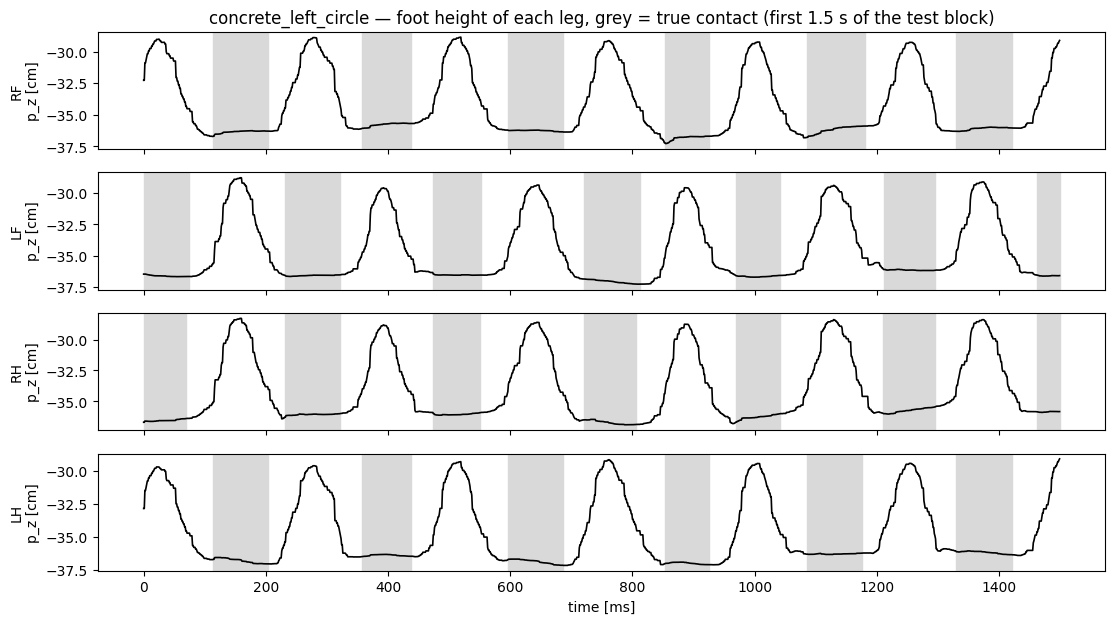

In [3]:
rec, e = "concrete_left_circle", test_ends["concrete_left_circle"][:SLICE]
X, y = recs[rec]
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(13, 7))
for k, (ax, leg) in enumerate(zip(axes, LEGS)):
    ax.fill_between(e - e[0], 0, 1, where=y[e, k] == 1, step="mid", color="0.85", transform=ax.get_xaxis_transform())
    ax.plot(e - e[0], 100 * X[e, P_Z[k]], color="k", lw=1.2)
    ax.set_ylabel(f"{leg}\np_z [cm]")
axes[0].set_title(f"{rec} — foot height of each leg, grey = true contact (first 1.5 s of the test block)")
axes[-1].set_xlabel("time [ms]"); plt.show()

- **Contact = the foot at the bottom of its trajectory**: each grey block sits on the flat low part of `p_z`
  (the labels were computed from it).
- **Trot**: diagonal pairs move together — RF with LH, LF with RH — and the two pairs alternate (stride ≈ 240 ms).

## 2. Trot on concrete — the easy case

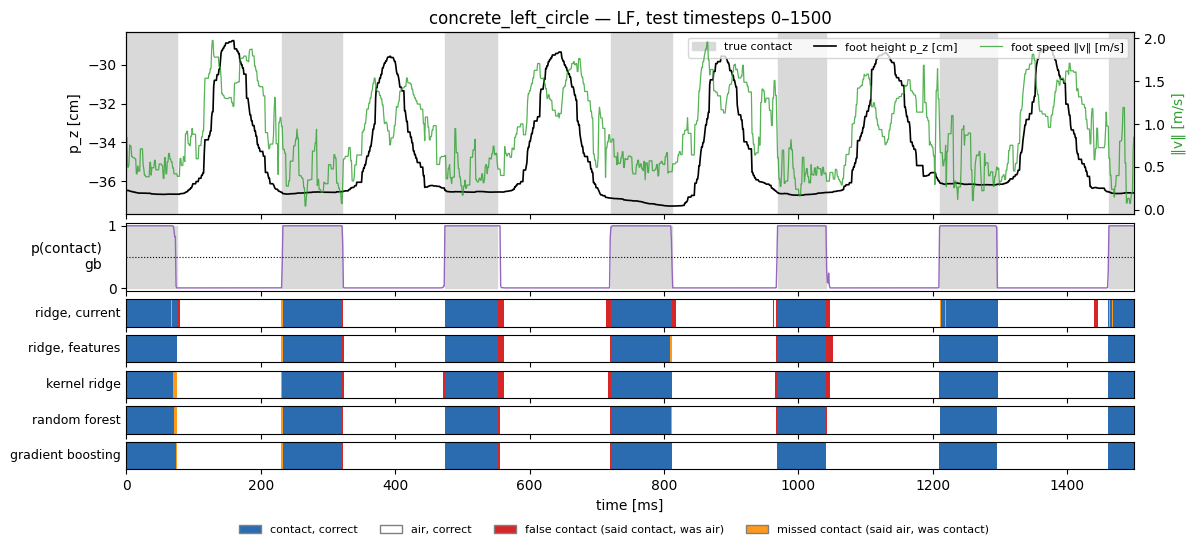

In [4]:
show("concrete_left_circle", proba=True)

- **Gradient boosting's probability is almost a clean step**: ~0 in swing, ~1 in stance, switching at the label edges;
  its errors are a few milliseconds at touchdown / lift-off.
- **Ridge on the current timestep** misses the first milliseconds of stance (orange), keeps "contact" a few ms after
  lift-off (red), and adds short spurious contacts in swing.
- Ridge on features and kernel ridge: stance well covered, but lift-off often called a few ms late (red slivers at the
  end of each stance).

## 3. Pronking — where history matters most

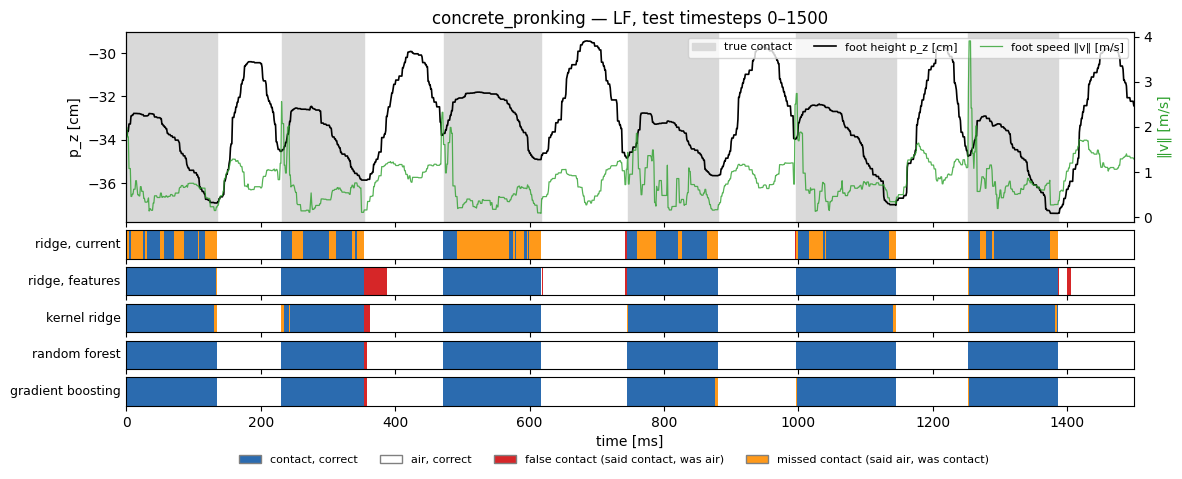

In [5]:
show("concrete_pronking")

- **Here an instant is not enough**: during stance the foot does **not** sit still at a fixed height — `p_z` changes by
  several cm and the foot speed stays around 0.5–1 m/s (body and legs compress and extend while the foot is on the
  ground). A threshold on the current values cannot find it: **ridge on the current timestep misses most of every
  stance** (orange).
- With the window features ridge finds the stances (one ~30 ms false contact after a lift-off); the forest and boosting
  are almost perfect on this slice.

## 4. Galloping — the hardest recording

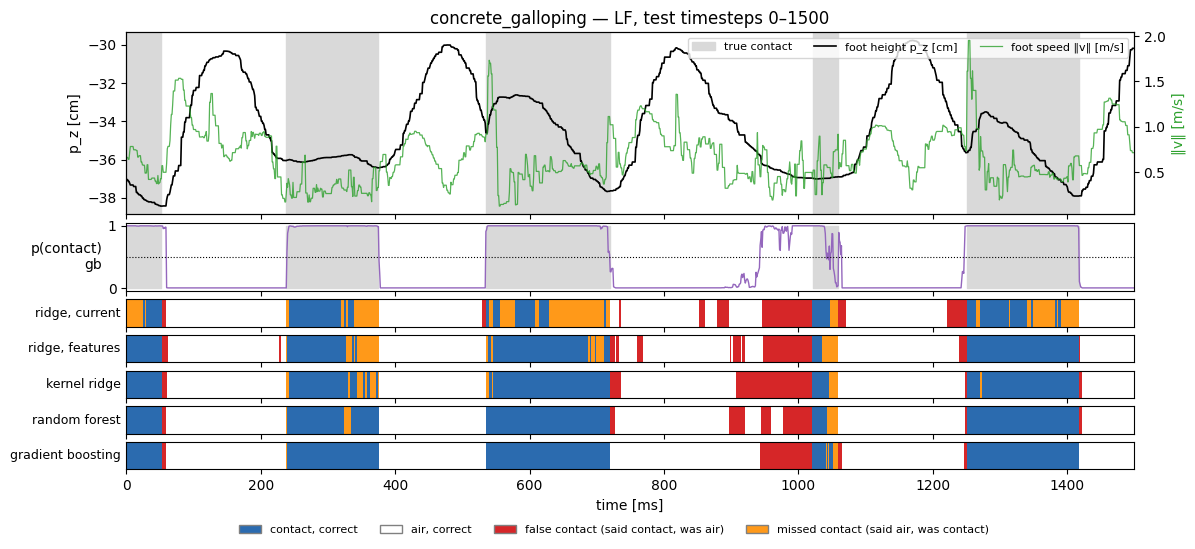

In [6]:
show("concrete_galloping", proba=True)

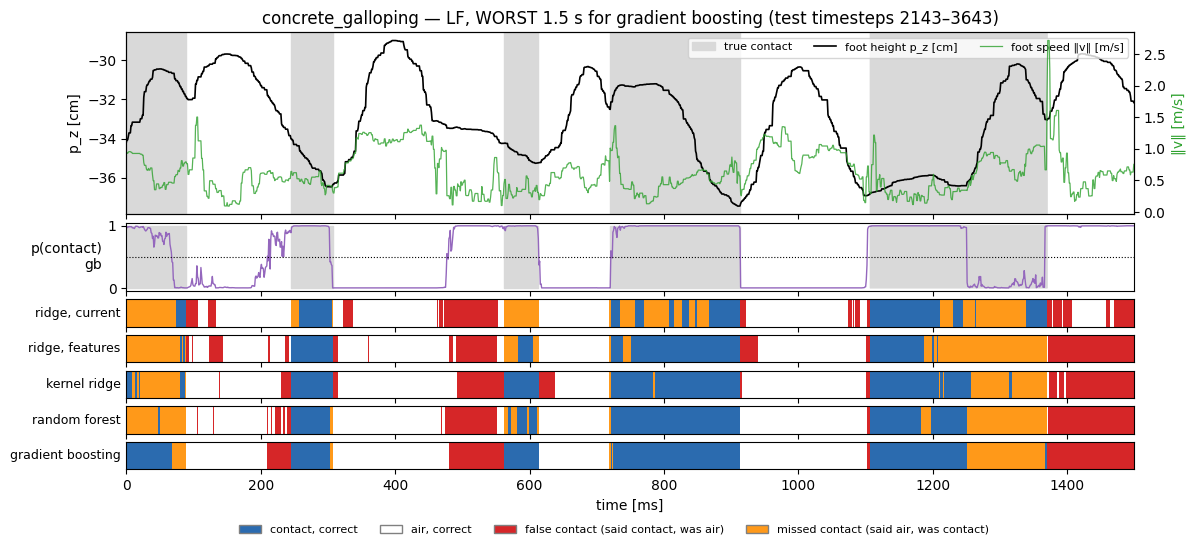

In [7]:
s = worst_start("concrete_galloping")
show("concrete_galloping", start=s, proba=True,
     title=f"concrete_galloping — LF, WORST 1.5 s for gradient boosting (test timesteps {s}–{s + SLICE})")

- **First slice**: the four stances are found by every window model; around 900–1,020 ms **all five models say contact
  while the label says air**. The foot is at its lowest and slow there for ~150 ms, but the label marks only ~40 ms of
  contact (1,020–1,060 ms).
- **Worst slice for boosting**: the long errors are again **shared by all models** — e.g. 1,250–1,370 ms the label stays
  "contact" while the foot rises by ~6 cm (every model says air: orange), then every model says contact where the label
  says air.
- When every model, linear or not, disagrees with the label in the same block, the label is the likely culprit: it is
  computed offline from foot height with a different cut-off for gallop (`PROGRESS.md`, Phase 1). Part of galloping's
  low F1 is probably label noise, not model error — a point for the discussion, not a proof.

## 5. Robot in the air — false contacts

The legs swing, nothing touches the ground: every predicted contact is a false contact.

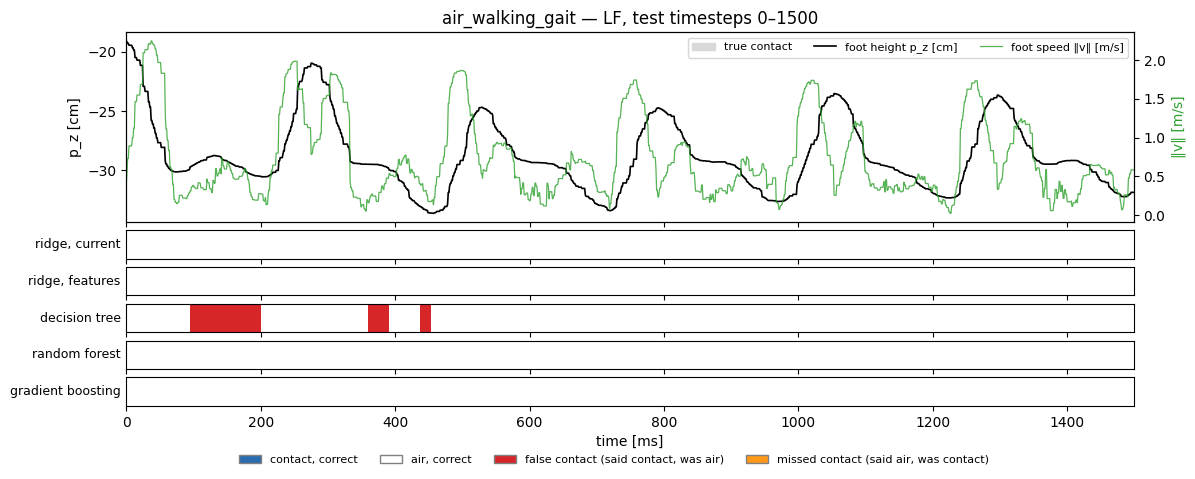

In [8]:
show("air_walking_gait", models=["ridge_current", "ridge_feat_all", "tree_feat_all", "rf_feat_all", "gb_feat_all"])

In [9]:
pd.DataFrame({NAMES[m]: {leg: preds[m][offset["air_walking_gait"]:offset["air_walking_gait"] + len(test_ends["air_walking_gait"]), k].mean()
                          for k, leg in enumerate(LEGS)} for m in NAMES}).T.round(3).rename_axis("false-contact rate, air_walking_gait")

,RF,LF,RH,LH
"false-contact rate, air_walking_gait",,,,
"ridge, current",0.006,0.000,0.000,0.010
"ridge, features",0.000,0.000,0.000,0.000
kernel ridge,0.000,0.000,0.000,0.000
decision tree,0.043,0.024,0.028,0.081
random forest,0.000,0.000,0.000,0.000
gradient boosting,0.000,0.000,0.000,0.000


- **The single tree is the only model with false contacts here** (2.4–8.1% per leg): blocks of tens of ms when the
  swinging foot passes low and slow (e.g. 100–200 ms), which a single threshold path mistakes for stance.
- Forest and boosting: **zero false contacts** on every leg — averaging many trees removes exactly this kind of
  single-path mistake. Ridge on the current timestep: at most 1% (RF, LH).

## 6. Where do the errors happen?

For every error (all legs, all ground recordings): its distance in ms to the nearest true touchdown or lift-off.
Errors close to a transition are **timing disagreements** with a label that is itself a smoothed, non-causal estimate;
errors far from any transition are **wrong contacts in the middle of a stance or swing**.

In [10]:
def error_distances(m):
    """Distance [ms] from each error to the nearest true label transition, ground recordings only."""
    out = []
    for rec, e in test_ends.items():
        y = recs[rec][1][e]
        if not y.any():
            continue  # air recordings: no transitions
        p = preds[m][offset[rec]:offset[rec] + len(e)]
        for k in range(4):
            tr = np.flatnonzero(np.diff(y[:, k].astype(int))) + 0.5  # between the two timesteps
            err = np.flatnonzero(p[:, k] != y[:, k])
            pos = np.clip(np.searchsorted(tr, err), 1, len(tr) - 1)
            out.append(np.minimum(np.abs(err - tr[pos - 1]), np.abs(err - tr[pos])))
    return np.concatenate(out)

dist = {NAMES[m]: error_distances(m) for m in NAMES}
pd.DataFrame({name: {"errors (ground)": len(d), **{f"within {w} ms": np.mean(d <= w) for w in (5, 10, 20, 50)},
                     "median [ms]": np.median(d)} for name, d in dist.items()}).T.round(3)

,errors (ground),within 5 ms,within 10 ms,within 20 ms,within 50 ms,median [ms]
"ridge, current",60941.0,0.274,0.438,0.620,0.885,12.5
"ridge, features",21596.0,0.588,0.763,0.860,0.945,3.5
kernel ridge,17727.0,0.654,0.808,0.887,0.955,3.5
decision tree,22948.0,0.520,0.669,0.778,0.923,4.5
random forest,13271.0,0.693,0.806,0.867,0.942,2.5
gradient boosting,11202.0,0.721,0.815,0.870,0.944,2.5


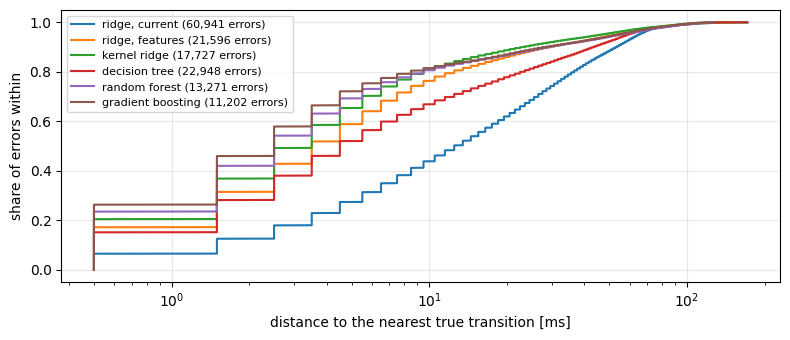

In [11]:
plt.figure(figsize=(8, 3.5))
for name, d in dist.items():
    x = np.sort(d)
    plt.plot(x, np.arange(1, len(x) + 1) / len(x), label=f"{name} ({len(d):,} errors)")
plt.xscale("log"); plt.xlabel("distance to the nearest true transition [ms]")
plt.ylabel("share of errors within"); plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

- **Gradient boosting: 72% of its errors are within 5 ms of a true transition, 82% within 10 ms (median 2.5 ms).**
  Joint/foot data update only every ~2–5 ms (500 Hz upsampled), so these are disagreements of one or two sensor
  readings about *when* the foot touched down or lifted off — on a label that is itself a smoothed, offline estimate.
- **Ridge on the current timestep**: only 27% within 5 ms (median 12.5 ms) — its errors are real mistakes inside stance
  or swing. The better the model, the more its errors move to the transitions: ridge features 59% → kernel ridge 65% →
  forest 69% → boosting 72%.
- **The single tree** sits below ridge on features (52% within 5 ms): more of its errors are mid-phase (section 5).
- Errors far from any transition are rare for boosting: 13% are more than 20 ms away — ~1,500 leg-timesteps, 0.25% of
  all scored — and section 4 suggests many of them are galloping label disagreements.